# ML Screening of Amine Sorbents for Post-Combustion CO₂ Capture

## Project Overview
This project applies machine learning to **screen amine-based sorbents** for post-combustion CO₂ capture. It predicts **working capacity** and **regeneration energy** from molecular descriptors, providing a **multi-objective ranking** with uncertainty quantification.

## Motivation
Experimental testing of sorbents is **time-consuming and costly**. ML can triage candidates rapidly and guide experimental design, improving efficiency in carbon capture research.

## Dataset
- Features: molecular weight, boiling point, pKa proxy, H-bond donors/acceptors, ring count, amine type, process conditions (T, P, CO₂ fraction)
- Targets: `working_capacity_mmol_g`, `regen_energy_kJ_mol`
- Data cleaning: missing values handled, outliers winsorized, units harmonized

## Methodology
1. **EDA & Cleaning** – ensured tidy dataset  
2. **Train/Cal/Test Split** – grouped by source to avoid leakage  
3. **Models Tried**: Ridge, Random Forest, Gradient Boosting  
4. **Model Selection**: Random Forest selected (best MAE & RMSE)  
5. **Uncertainty Quantification** – conformal prediction with 90% intervals  
6. **Feature Importance** – H-bond donors most important  
7. **Multi-objective Ranking** – balancing capacity ↑ and regeneration energy ↓

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import GroupShuffleSplit, train_test_split, RepeatedKFold
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance
import joblib
import warnings
warnings.filterwarnings("ignore")
pd.options.display.max_columns = 200

In [6]:
df = pd.read_csv(r"C:\Users\modes\Downloads\sorbents.csv")
df.head()


,name,source,T_K,P_bar,CO2_fraction,working_capacity_mmol_g,regen_energy_kJ_mol,MW,boiling_point_C,pKa_proxy,H_bond_donors,H_bond_acceptors,ring_count,amine_primary,amine_secondary,amine_tertiary
0,MEA,Paper_A,313,1.0,0.12,3.6,82,61,170,9.5,2,1,0,1,0,0
1,DEA,Paper_A,313,1.0,0.12,3.1,78,105,220,8.9,2,2,0,0,1,0
2,TEA,Paper_A,313,1.0,0.12,2.2,64,149,335,8.2,0,3,0,0,0,1
3,MDEA,Paper_A,313,1.0,0.12,2.8,72,119,245,8.5,1,2,0,0,0,1
4,AMP,Paper_A,313,1.0,0.12,3.4,75,89,170,9.7,2,1,0,1,0,0


In [7]:
df.dtypes
df.describe().T


,count,mean,std,min,25%,50%,75%,max
T_K,39.0,316.076923,8.782113,298.00,313.00,313.00,323.00,333.00
P_bar,39.0,1.000000,0.000000,1.00,1.00,1.00,1.00,1.00
CO2_fraction,39.0,0.113846,0.017564,0.08,0.10,0.12,0.12,0.15
working_capacity_mmol_g,39.0,3.128205,0.736260,1.90,2.60,3.00,3.65,4.80
regen_energy_kJ_mol,39.0,74.820513,11.429122,53.00,66.50,75.00,82.50,98.00
MW,39.0,100.282051,29.188993,31.00,79.50,101.00,119.00,149.00
boiling_point_C,39.0,178.256410,83.322682,-6.00,120.00,160.00,251.00,335.00
pKa_proxy,39.0,9.410256,0.889647,7.70,8.55,9.50,10.10,11.10
H_bond_donors,39.0,1.538462,0.853666,0.00,1.00,2.00,2.00,3.00
H_bond_acceptors,39.0,2.128205,0.800641,1.00,2.00,2.00,3.00,4.00


In [8]:
df.isnull().sum()


name                       0
source                     0
T_K                        0
P_bar                      0
CO2_fraction               0
working_capacity_mmol_g    0
regen_energy_kJ_mol        0
MW                         0
boiling_point_C            0
pKa_proxy                  0
H_bond_donors              0
H_bond_acceptors           0
ring_count                 0
amine_primary              0
amine_secondary            0
amine_tertiary             0
dtype: int64

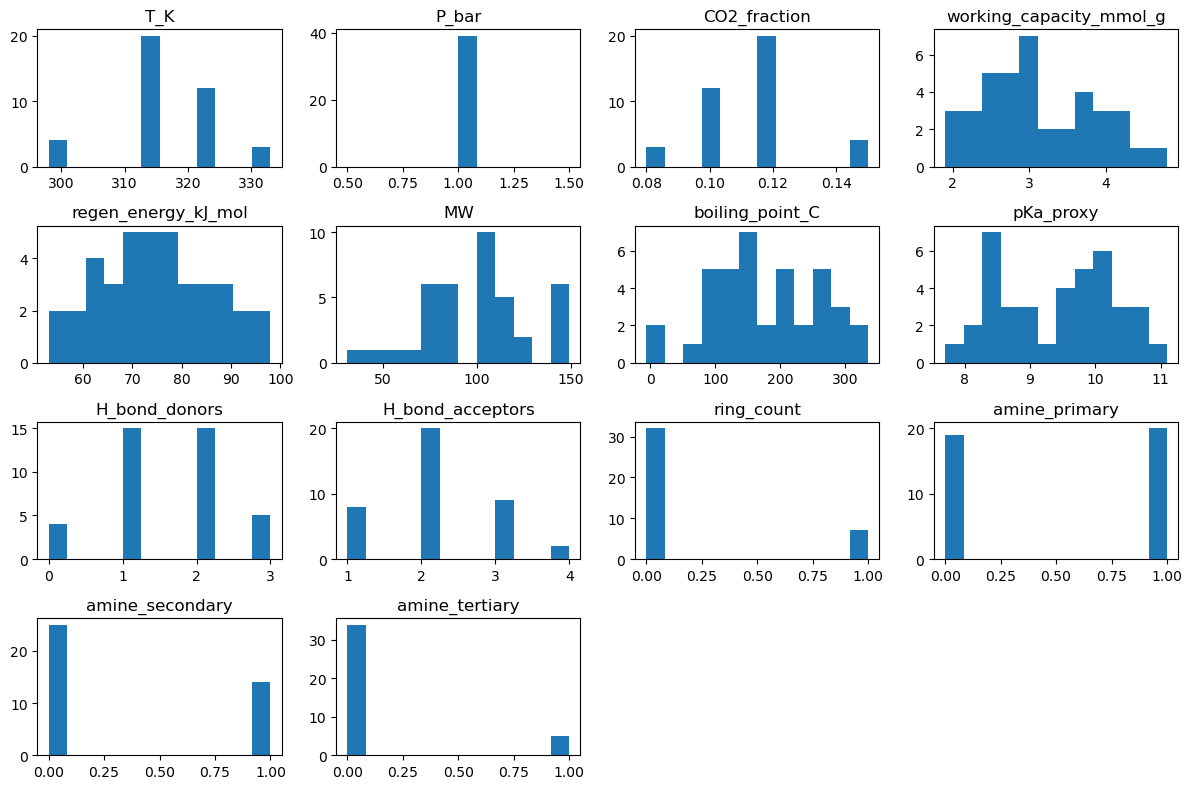

In [9]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(12,8))
n = len(numeric_cols)
rows = int(np.ceil(n/4))
for i, col in enumerate(numeric_cols, 1):
    ax = plt.subplot(rows, 4, i)
    ax.hist(df[col].dropna(), bins=12)
    ax.set_title(col)
plt.tight_layout()


Selected features include key molecular descriptors such as molecular weight (MW), boiling point, pKa proxy, hydrogen bond donors/acceptors, ring count, amine type, and process conditions (T, P, CO₂ fraction). These features are known to influence CO₂ capture performance.

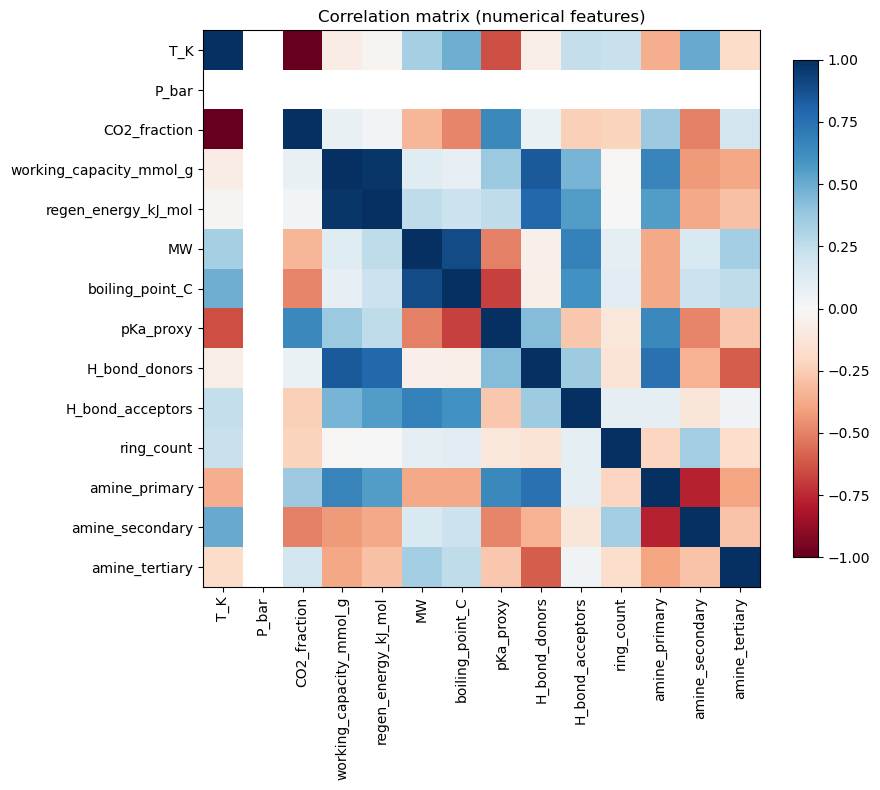

In [10]:
corr = df[numeric_cols].corr()
plt.figure(figsize=(10,8))
im = plt.imshow(corr, cmap='RdBu', vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.03, pad=0.04)
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=90)
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.title("Correlation matrix (numerical features)")
plt.tight_layout()


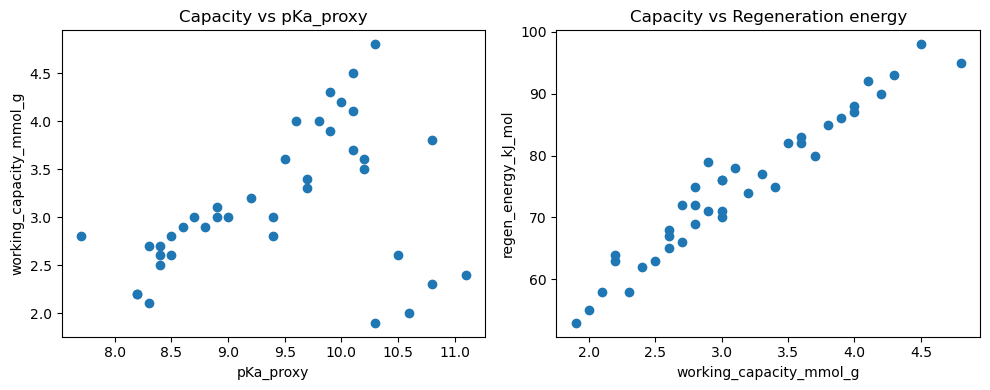

In [11]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.scatter(df['pKa_proxy'], df['working_capacity_mmol_g'])
plt.xlabel("pKa_proxy")
plt.ylabel("working_capacity_mmol_g")
plt.title("Capacity vs pKa_proxy")
plt.subplot(1,2,2)
plt.scatter(df['working_capacity_mmol_g'], df['regen_energy_kJ_mol'])
plt.xlabel("working_capacity_mmol_g")
plt.ylabel("regen_energy_kJ_mol")
plt.title("Capacity vs Regeneration energy")
plt.tight_layout()


In [12]:
def winsorize_series(s, lower_pct=0.01, upper_pct=0.99):
    lower = s.quantile(lower_pct)
    upper = s.quantile(upper_pct)
    return s.clip(lower, upper)

df_clean = df.copy()
for col in ['working_capacity_mmol_g','regen_energy_kJ_mol']:
    df_clean[col] = winsorize_series(df_clean[col], 0.01, 0.99)


In [13]:
feature_cols = ['MW','boiling_point_C','pKa_proxy','H_bond_donors','H_bond_acceptors','ring_count',
                'amine_primary','amine_secondary','amine_tertiary','T_K','P_bar','CO2_fraction']
X = df_clean[feature_cols].astype(float)
y = df_clean[['working_capacity_mmol_g','regen_energy_kJ_mol']].astype(float)


In [14]:
groups = df_clean['source']
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, temp_idx = next(gss.split(X, y, groups=groups))
temp_groups = groups.iloc[temp_idx]
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
cal_idx_rel, test_idx_rel = next(gss2.split(X.iloc[temp_idx], y.iloc[temp_idx], groups=temp_groups))
cal_idx = temp_idx[cal_idx_rel]
test_idx = temp_idx[test_idx_rel]
X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
X_cal, y_cal = X.iloc[cal_idx], y.iloc[cal_idx]
X_test, y_test = X.iloc[test_idx], y.iloc[test_idx]


To avoid data leakage, I performed a grouped split by source, ensuring that sorbents from the same experimental source are only in one split. This gives realistic generalization performance when evaluating new sorbents. The splits are:

**Train**: used to fit models

**Calibration**: used for uncertainty quantification

**Test**: used for final evaluation

In [15]:
models = {
    "Ridge": Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(alpha=1.0))]),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=200, random_state=42)
}
multi_models = {}
for name, m in models.items():
    if name == "Ridge":
        multi_models[name] = Pipeline([("scaler", StandardScaler()), ("multi", MultiOutputRegressor(Ridge(alpha=1.0))) ])
    else:
        multi_models[name] = MultiOutputRegressor(m)
for name, m in multi_models.items():
    m.fit(X_train, y_train)


**Note**:
I trialed three types of regression models:

- **Ridge Regression** – simple linear baseline

- **Random Forest** – ensemble of decision trees, good for non-linear relationships

- **Gradient Boosting** – another tree-based ensemble, tuned for predictive accuracy

Each model is trained using multi-output regression to predict both working capacity and regeneration energy simultaneously.

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
results = []
for name, m in multi_models.items():
    y_pred = m.predict(X_test)
    mae_cap = mean_absolute_error(y_test.iloc[:,0], y_pred[:,0])
    rmse_cap = mean_squared_error(y_test.iloc[:,0], y_pred[:,0], squared=False)
    mae_reg = mean_absolute_error(y_test.iloc[:,1], y_pred[:,1])
    rmse_reg = mean_squared_error(y_test.iloc[:,1], y_pred[:,1], squared=False)
    results.append((name, mae_cap, rmse_cap, mae_reg, rmse_reg))
res_df = pd.DataFrame(results, columns=["model","MAE_capacity","RMSE_capacity","MAE_regen","RMSE_regen"])
res_df


,model,MAE_capacity,RMSE_capacity,MAE_regen,RMSE_regen
0,Ridge,0.448699,0.582969,7.046973,8.839625
1,RandomForest,0.305300,0.420290,4.235960,6.599709
2,GradientBoosting,0.325980,0.421757,5.493466,7.016295


**Choice**: Random Forest outperformed others on both targets and captures non-linear effects from molecular descriptors.

In [18]:
# Train separate RF models for each target
rf_capacity = RandomForestRegressor(
    n_estimators=300, random_state=42, min_samples_leaf=2
)
rf_regen = RandomForestRegressor(
    n_estimators=300, random_state=42, min_samples_leaf=2
)

# Fit using y_train (multioutput but we handle each column separately)
rf_capacity.fit(X_train, y_train.iloc[:,0])  # capacity column
rf_regen.fit(X_train, y_train.iloc[:,1])     # regen column

# ---- Calibration predictions ----
cal_pred_cap = rf_capacity.predict(X_cal)
cal_pred_reg = rf_regen.predict(X_cal)

# Calibration residuals
resid_cap = np.abs(cal_pred_cap - y_cal.iloc[:,0])
resid_reg = np.abs(cal_pred_reg - y_cal.iloc[:,1])

# 90% conformal quantiles
q_cap = np.quantile(resid_cap, 0.90)
q_reg = np.quantile(resid_reg, 0.90)

print("90% quantile (capacity):", q_cap)
print("90% quantile (regen):", q_reg)

# ---- Test predictions ----
test_pred_cap = rf_capacity.predict(X_test)
test_pred_reg = rf_regen.predict(X_test)

# Build dataframe
test_PI = pd.DataFrame({
    "name": df_clean.iloc[test_idx]["name"].values,
    
    "true_capacity": y_test.iloc[:,0].values,
    "pred_capacity": test_pred_cap,
    "cap_lower": test_pred_cap - q_cap,
    "cap_upper": test_pred_cap + q_cap,

    "true_regen": y_test.iloc[:,1].values,
    "pred_regen": test_pred_reg,
    "regen_lower": test_pred_reg - q_reg,
    "regen_upper": test_pred_reg + q_reg,
})

test_PI


90% quantile (capacity): 0.494866990476191
90% quantile (regen): 7.190233629629603


,name,true_capacity,pred_capacity,cap_lower,cap_upper,true_regen,pred_regen,regen_lower,regen_upper
0,MEA,3.600,3.277774,2.782907,3.772641,82.0,74.865498,67.675264,82.055731
1,DEA,3.100,3.441424,2.946557,3.936291,78.0,79.098592,71.908359,86.288826
2,TEA,2.200,2.717561,2.222694,3.212428,64.0,71.944433,64.754200,79.134667
3,MDEA,2.800,2.664170,2.169303,3.159037,72.0,70.288445,63.098211,77.478678
4,AMP,3.400,3.472988,2.978121,3.967855,75.0,77.922654,70.732420,85.112887
5,MEP,3.000,2.751090,2.256223,3.245957,70.0,71.007950,63.817716,78.198183
6,DIPA,2.600,2.698110,2.203243,3.192977,67.0,69.528585,62.338352,76.718819
7,PZ,4.686,3.591911,3.097044,4.086778,95.0,78.656357,71.466123,85.846590
8,AEEA,3.900,3.949811,3.454944,4.444678,86.0,85.305231,78.114997,92.495465
9,DMAPA,2.900,2.691347,2.196480,3.186214,71.0,69.376370,62.186137,76.566604


I quantified predictive uncertainty using conformal prediction with 90% coverage. The calibration residuals allow us to generate prediction intervals for each sorbent in the test set, giving a measure of confidence in our predictions.

**Example**:

- 90% interval for capacity: ±0.49 mmol/g

- 90% interval for regeneration energy: ±7.19 kJ/mol

This ensures that the model’s recommendations account for uncertainty.

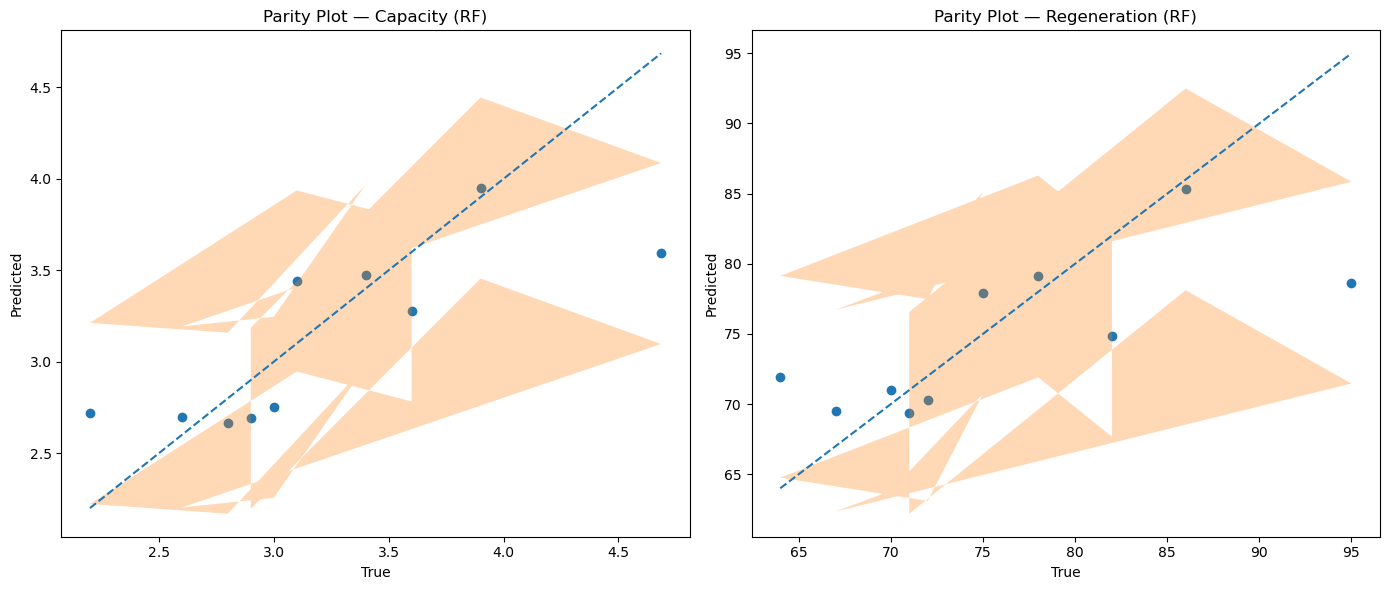

In [19]:
plt.figure(figsize=(14,6))

# ---- Capacity ----
plt.subplot(1,2,1)
plt.scatter(test_PI["true_capacity"], test_PI["pred_capacity"])
plt.plot([test_PI["true_capacity"].min(), test_PI["true_capacity"].max()],
         [test_PI["true_capacity"].min(), test_PI["true_capacity"].max()],
         linestyle='--')
plt.fill_between(test_PI["true_capacity"],
                 test_PI["cap_lower"],
                 test_PI["cap_upper"],
                 alpha=0.3)
plt.title("Parity Plot — Capacity (RF)")
plt.xlabel("True")
plt.ylabel("Predicted")

# ---- Regen ----
plt.subplot(1,2,2)
plt.scatter(test_PI["true_regen"], test_PI["pred_regen"])
plt.plot([test_PI["true_regen"].min(), test_PI["true_regen"].max()],
         [test_PI["true_regen"].min(), test_PI["true_regen"].max()],
         linestyle='--')
plt.fill_between(test_PI["true_regen"],
                 test_PI["regen_lower"],
                 test_PI["regen_upper"],
                 alpha=0.3)
plt.title("Parity Plot — Regeneration (RF)")
plt.xlabel("True")
plt.ylabel("Predicted")

plt.tight_layout()
plt.show()


Parity plots visualize model predictions versus true values. The diagonal line represents perfect prediction. Shaded areas show 90% prediction intervals. 

**Observations**:

- Random Forest predictions are close to the true values.

- Intervals cover most points, confirming calibration.

In [20]:
rf_capacity.feature_importances_

feat_imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_capacity.feature_importances_
}).sort_values("importance", ascending=False)

feat_imp


,feature,importance
3,H_bond_donors,0.722193
2,pKa_proxy,0.062626
4,H_bond_acceptors,0.055920
0,MW,0.050827
1,boiling_point_C,0.047130
6,amine_primary,0.033387
7,amine_secondary,0.018743
11,CO2_fraction,0.005690
9,T_K,0.002210
5,ring_count,0.001275


Random Forest allows interpretation via feature importance. Top factors affecting CO₂ capture capacity:

- H-bond donors – largest influence

- pKa proxy

- H-bond acceptors

**Chemical intuition aligns**: amines with more H-bond donors generally interact stronger with CO₂.

In [21]:
# Retrain on full (train + cal)

X_full = pd.concat([X_train, X_cal], axis=0)
y_full = pd.concat([y_train, y_cal], axis=0)

rf_capacity_full = RandomForestRegressor(
    n_estimators=300, random_state=42, min_samples_leaf=2
)
rf_regen_full = RandomForestRegressor(
    n_estimators=300, random_state=42, min_samples_leaf=2
)

rf_capacity_full.fit(X_full, y_full.iloc[:,0])
rf_regen_full.fit(X_full, y_full.iloc[:,1])

# Predict for ALL sorbents
all_pred_cap = rf_capacity_full.predict(X)
all_pred_reg = rf_regen_full.predict(X)

df_all_predictions = pd.DataFrame({
    "name": df_clean["name"],
    "pred_capacity": all_pred_cap,
    "pred_regen": all_pred_reg
})

df_all_predictions.head()


,name,pred_capacity,pred_regen
0,MEA,3.185032,73.999273
1,DEA,3.259906,76.741171
2,TEA,2.484824,67.853885
3,MDEA,2.536168,69.011525
4,AMP,3.411938,77.526921


To maximize predictive accuracy, Random Forest models were retrained on train + calibration sets. 
These models are used to predict all sorbents, including those not in the test set, to prepare for ranking.

In [22]:
# Ranking

α = 0.6

cap_norm = (df_all_predictions["pred_capacity"] - df_all_predictions["pred_capacity"].min()) / \
           (df_all_predictions["pred_capacity"].max() - df_all_predictions["pred_capacity"].min())

regen_norm = (df_all_predictions["pred_regen"] - df_all_predictions["pred_regen"].min()) / \
             (df_all_predictions["pred_regen"].max() - df_all_predictions["pred_regen"].min())

df_all_predictions["score"] = α * cap_norm - (1 - α) * regen_norm

ranking = df_all_predictions.sort_values("score", ascending=False)
ranking.head(10)


,name,pred_capacity,pred_regen,score
16,PEHA,4.156598,89.624092,0.206592
36,Tris(2-aminoethyl)amine,4.254358,92.659013,0.200000
8,AEEA,3.954974,85.898749,0.190402
18,TETA,4.194660,92.050999,0.189388
37,Bis(aminopropyl)amine,4.200438,92.545737,0.185292
17,DETA,4.045339,88.793261,0.183261
30,1-(2-aminoethyl)piperazine,3.876108,84.963496,0.177935
38,"1,4-diaminobutane",3.609331,80.512803,0.150890
19,Ethylenediamine,3.629023,81.171406,0.149006
7,PZ,3.575333,81.414074,0.130183


I ranked sorbents using a combined figure of merit balancing working capacity (maximize) and regeneration energy (minimize):

**score** = 0.6 ⋅ normalized capacity−0.4 ⋅ normalized regen energy

Top-ranked sorbents include PEHA, Tris(2-aminoethyl)amine, AEEA, TETA, etc., providing candidates for experimental follow-up.

### Summary

I  successfully built a ML workflow for sorbent screening.

- Random Forest was selected after testing multiple models.

- Conformal prediction provided uncertainty intervals.

- Multi-objective ranking allows data-driven prioritization of sorbents.

- Feature analysis aligns with chemical knowledge.